In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [7]:
df = pd.read_csv("student_habits_performance.csv")

df = df.dropna()  # eliminar valores nulos

z = np.abs(stats.zscore(df.select_dtypes(include=np.number)))
df = df[(z < 3).all(axis=1)]  # remover outliers
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [8]:
print("Tipos de datos en el DataFrame:")
print(df.dtypes)

print("\nColumnas que NO son numéricas:")
print(df.select_dtypes(exclude=['int64', 'float64']).columns)

Tipos de datos en el DataFrame:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64
dtype: object

Columnas que NO son numéricas:
Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')


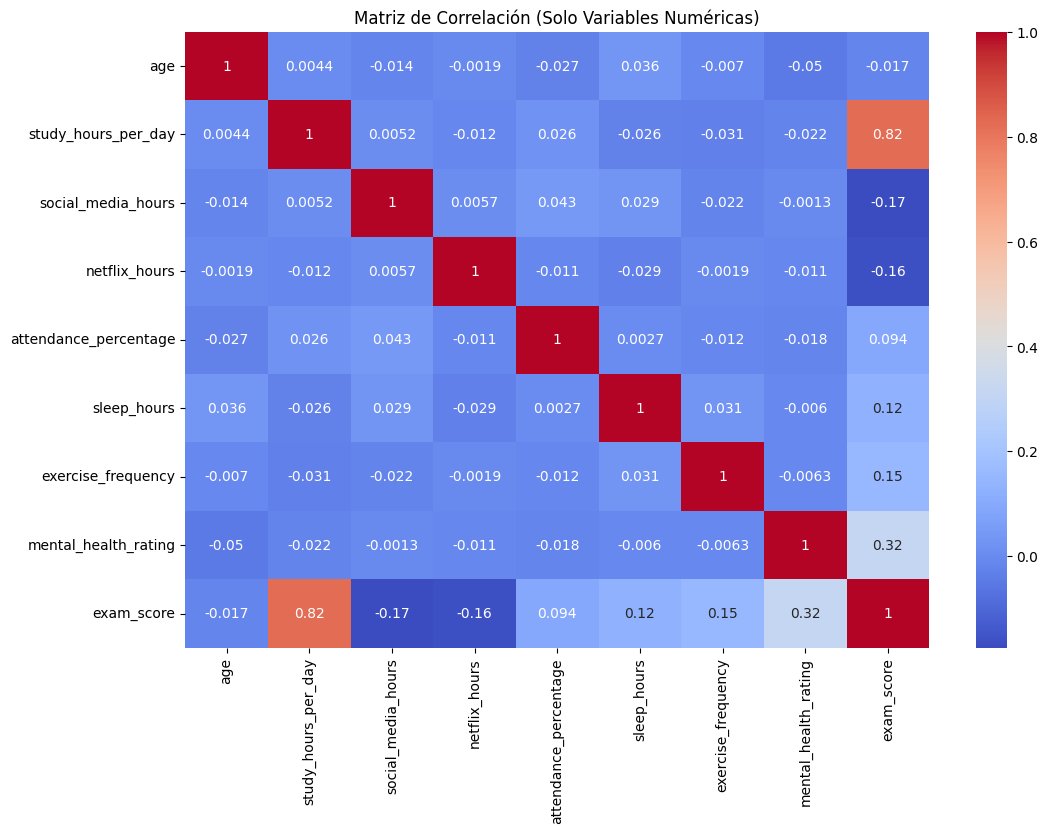

In [9]:
df_num = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación (Solo Variables Numéricas)")
plt.show()

In [10]:
df = pd.read_csv("student_habits_performance.csv")

df = df.dropna()  # eliminar valores nulos

z = np.abs(stats.zscore(df.select_dtypes(include=np.number)))
df = df[(z < 3).all(axis=1)]  # remover outliers
df.head()


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [11]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000
mean,20.478357,3.530744,2.488457,1.821199,83.865927,6.473363,3.054384,5.467259,69.559600
std,2.301890,1.454922,1.146008,1.059583,9.480501,1.218150,2.035882,2.860125,16.820248
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,23.100000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.500000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,7.600000,5.700000,5.000000,100.000000,10.000000,6.000000,10.000000,100.000000


**Matriz de correlación**

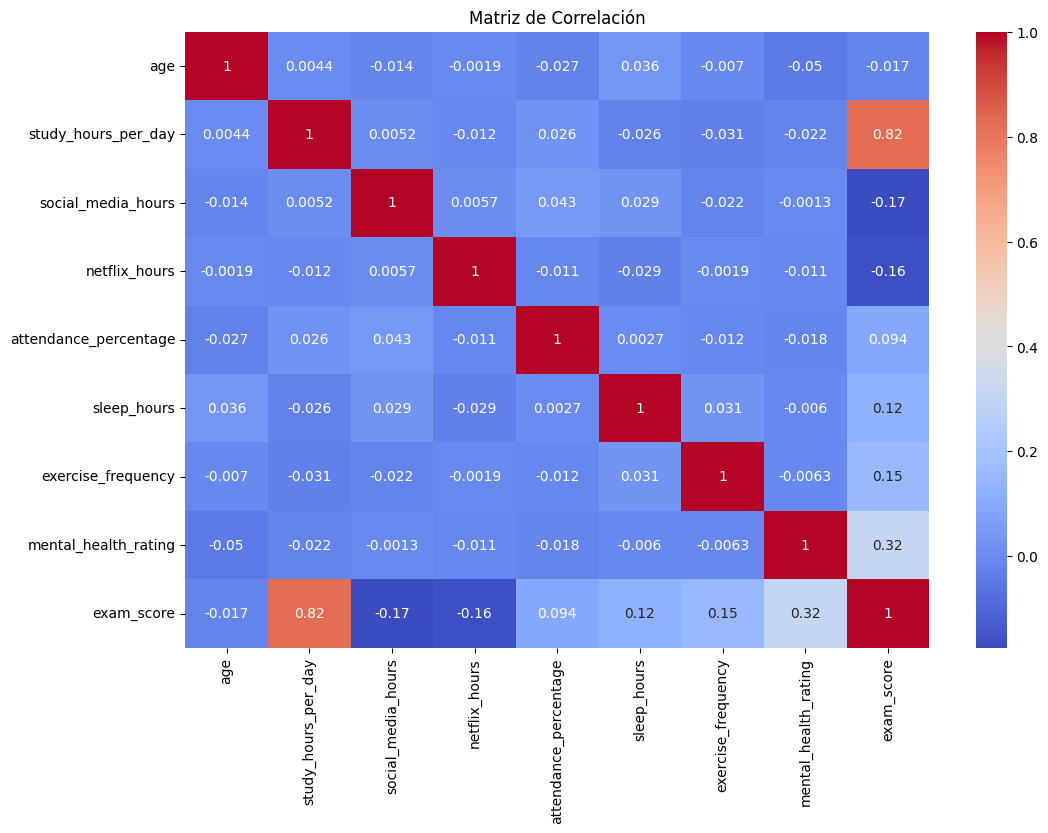

In [12]:
df_num = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

##**Regresión lineal simple**

In [13]:
X = df[['sleep_hours']]
y = df['exam_score']
# Ajustar modelo sklearn
modelo_simple = LinearRegression()
modelo_simple.fit(X, y)

# Parámetros
b0 = modelo_simple.intercept_
b1 = modelo_simple.coef_[0]

print("Intercepto (β0):", b0)
print("Pendiente (β1):", b1)

Intercepto (β0): 58.452467193713375
Pendiente (β1): 1.7158211844773683


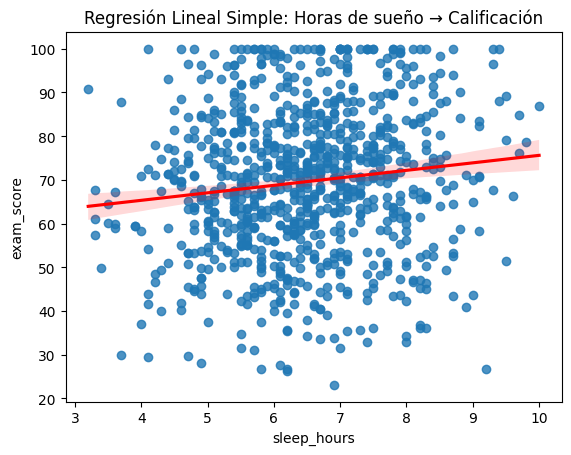

In [14]:
#Gráfica de regresión
sns.regplot(x='sleep_hours', y='exam_score', data=df, line_kws={'color':'red'})
plt.title("Regresión Lineal Simple: Horas de sueño → Calificación")
plt.show()

In [15]:
# Modelo con statsmodels (para p-values)
X_sm = sm.add_constant(X)
modelo_sm_simple = sm.OLS(y, X_sm).fit()
print(modelo_sm_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     14.10
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           0.000185
Time:                        16:33:27   Log-Likelihood:                -3814.1
No. Observations:                 901   AIC:                             7632.
Df Residuals:                     899   BIC:                             7642.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          58.4525      3.010     19.420      

##**Regresión lineal Multiple**

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [17]:
#SELECCIONAR VARIABLES
numerical_features = ['sleep_hours', 'study_hours_per_day', 'social_media_hours']
categorical_feature = 'diet_quality'

# Numéricas
X_numerical = df[numerical_features]

# Categórica → Dummy
X_categorical = pd.get_dummies(df[categorical_feature], drop_first=True, prefix='diet')

# Unimos
X = pd.concat([X_numerical, X_categorical], axis=1)

# Variable objetivo
y = df['exam_score']

In [18]:
#Convertir todo a numerico
# Convertir X
X = X.apply(pd.to_numeric, errors='coerce')

# Convertir y
y = pd.to_numeric(y, errors='coerce')

print("Dtypes después de convertir:")
print(X.dtypes)
print("Tipo de y:", y.dtype)


Dtypes después de convertir:
sleep_hours            float64
study_hours_per_day    float64
social_media_hours     float64
diet_Good                 bool
diet_Poor                 bool
dtype: object
Tipo de y: float64


In [19]:
#Eliminar filas con valores numéricos
df_clean = pd.concat([X, y], axis=1).dropna()

X = df_clean[X.columns]
y = df_clean['exam_score']

print("\nFilas finales después de limpiar:", X.shape)



Filas finales después de limpiar: (901, 5)


In [20]:
# 4. CONVERTIR A FLOAT (100% OBLIGATORIO)
X = X.astype(float)
y = y.astype(float)

print("\nTipos finales del modelo:")
print(X.dtypes, "\n")
print("Y dtype:", y.dtype)


Tipos finales del modelo:
sleep_hours            float64
study_hours_per_day    float64
social_media_hours     float64
diet_Good              float64
diet_Poor              float64
dtype: object 

Y dtype: float64


In [21]:
#Ajustar modelo
X_const = sm.add_constant(X)

modelo_multiple = sm.OLS(y, X_const).fit()

print("\n=== MODELO DE REGRESIÓN MÚLTIPLE ===\n")
print(modelo_multiple.summary())


=== MODELO DE REGRESIÓN MÚLTIPLE ===

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     484.8
Date:                Thu, 20 Nov 2025   Prob (F-statistic):          8.80e-252
Time:                        16:33:27   Log-Likelihood:                -3230.7
No. Observations:                 901   AIC:                             6473.
Df Residuals:                     895   BIC:                             6502.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

##**Validación del modelo**

In [22]:
import scipy.stats as stats
#Residuales del modelo
residuales = modelo_multiple.resid
ajustados = modelo_multiple.fittedvalues

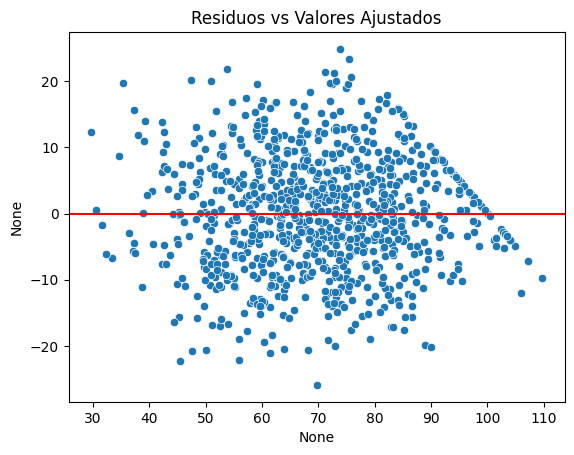

In [23]:
#Residuos vs Valores ajustados
sns.scatterplot(x=ajustados, y=residuales)
plt.axhline(0, color='red')
plt.title("Residuos vs Valores Ajustados")
plt.show()

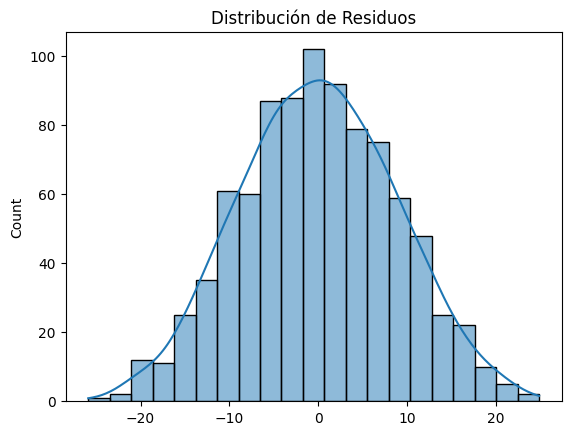

In [24]:
#Histogramas de residuos
sns.histplot(residuales, kde=True)
plt.title("Distribución de Residuos")
plt.show()

In [25]:

#Prueba de normalidad Shapiro-Wilk
shapiro_test = stats.shapiro(residuales)
print("Shapiro-Wilk Test:", shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9981569283798348), pvalue=np.float64(0.44549718888664736))


In [26]:
#R² del modelo
print("R²:", modelo_multiple.rsquared)
print("R² ajustado:", modelo_multiple.rsquared_adj)


R²: 0.7303344873819868
R² ajustado: 0.7288279761383107


##**Aplicación a la vida real**

In [27]:
prueba = pd.read_csv('datos.csv')
prueba.head()

,Marca temporal,Información general\n\n1. Ingresa tu edad,2. Género,Hábitos de estudio\n\n4. ¿Cuántas horas estudías al día?,5. ¿Tienes un trabajo?,Hábitos digitales\n\n6. ¿Cuántas horas pasas al día en redes sociales?,7. ¿Cuántas horas ves plataformas de streaming al día?,8. ¿Cómo describirías la calidad de tu conexión a Internet?,Asistencia y rendimiento académico\n\n9. ¿Qué porcentaje de tus clases sueles asistir?,10. ¿Cuál fue tu último puntaje de examen importante?,Salud y bienestar\n\n11. ¿Cuántas horas duermes?,12. ¿Cómo calificarías la calidad de tu alimentación?,13. ¿Con qué frecuencia haces ejercicio a la semana?,14. ¿Cómo evaluarías tu salud mental?,Estilo de vida y familia\n\n\n15. ¿Qué nivel educativo tienen tus padres o tutores?,16. ¿Participas en actividades extracurriculares?,17. Escribe en que materias consideras que tuviste dificultades,3. Carrera
0,13/11/2025 14:09:13,22,Femenino,0 a 2,Sí,más de 6,2 a 3,Excelente,51% a 75%,50,más de 6,Muy buena,1–2 veces,Excelente,Secundaria,"Sí, arte/música",Aprendizaje Automatico Supervisado y Metodos N...,Ciencia de Datos
1,18/11/2025 15:37:13,23,Masculino,0 a 2,No,0 a 3,2 a 3,Mala,51% a 75%,75,más de 6,Mala,Nunca,Regular,Preparatoria,No,Fisicoquimica y Fisiología Animal,Biología
2,18/11/2025 15:51:03,23,Femenino,0 a 2,No,más de 6,0 a 2,Buena,76% a 100%,50,más de 6,Regular,3–4 veces,Buena,Universidad,"Sí, deportes","Bioquímica , óptica y bioestadistica",Bioingeniería
3,18/11/2025 20:34:18,21,Masculino,0 a 2,Sí,0 a 3,0 a 2,Buena,76% a 100%,88,más de 6,Buena,5 o más veces,Buena,Universidad,"Sí, deportes",Operatoria,Odontología
4,19/11/2025 8:49:18,21,Femenino,0 a 2,Sí,0 a 3,0 a 2,Buena,76% a 100%,90,4 a 5,Buena,5 o más veces,Buena,Preparatoria,No,Diseño arquitectónico,Arquitectura


In [33]:
prueba['10. ¿Cuál fue tu último puntaje de examen importante?  '].unique()

array(['50', '75', '88', '90', '95', '80', '60', '65', '76', '103/100',
       '40', '86', '100', '57', '70', '70 de 100'], dtype=object)

In [37]:
for col in prueba.columns:
    print("\n---", col, "---")
    print(prueba[col].unique())


--- Marca temporal ---
['13/11/2025 14:09:13' '18/11/2025 15:37:13' '18/11/2025 15:51:03'
 '18/11/2025 20:34:18' '19/11/2025 8:49:18' '19/11/2025 11:50:34'
 '19/11/2025 11:58:59' '19/11/2025 11:59:57' '19/11/2025 12:12:22'
 '19/11/2025 12:23:05' '19/11/2025 13:34:20' '19/11/2025 13:38:43'
 '19/11/2025 13:39:59' '19/11/2025 13:44:58' '19/11/2025 14:57:31'
 '19/11/2025 15:25:36' '19/11/2025 17:48:04' '19/11/2025 20:58:50'
 '19/11/2025 20:59:55' '19/11/2025 21:00:36' '19/11/2025 21:01:00'
 '19/11/2025 21:35:24' '19/11/2025 21:52:10']

--- Información general

1. Ingresa tu edad ---
[22 23 21 29 25 19 32 18 24 20]

--- 2. Género ---
['Femenino' 'Masculino']

--- Hábitos de estudio

4. ¿Cuántas horas estudías al día? ---
['0 a 2' 'más de 4' '2 a 3']

--- 5.  ¿Tienes un trabajo?  ---
['Sí' 'No']

--- Hábitos digitales

6. ¿Cuántas horas pasas al día en redes sociales?  ---
['más de 6' '0 a 3' '4 a 5']

--- 7.   ¿Cuántas horas ves plataformas de streaming al día?  ---
['2 a 3' '0 a 2' 'más d

In [38]:
# Show uniques for relevant survey columns
cols_to_check = [
 '2. Género',
 'Hábitos de estudio\n\n4. ¿Cuántas horas estudías al día?',
 '5.  ¿Tienes un trabajo? ',
 'Hábitos digitales\n\n6. ¿Cuántas horas pasas al día en redes sociales? ',
 '7.   ¿Cuántas horas ves plataformas de streaming al día? ',
 '8.  ¿Cómo describirías la calidad de tu conexión a Internet? ',
 'Asistencia y rendimiento académico\n\n9.  ¿Qué porcentaje de tus clases sueles asistir?',
 '10. ¿Cuál fue tu último puntaje de examen importante?  ',
 'Salud y bienestar\n\n11.  ¿Cuántas horas duermes? ',
 '12.  ¿Cómo calificarías la calidad de tu alimentación? ',
 '13.  ¿Con qué frecuencia haces ejercicio a la semana? ',
 '14.  ¿Cómo evaluarías tu salud mental? ',
 'Estilo de vida y familia\n\n\n15. ¿Qué nivel educativo tienen tus padres o tutores?',
 '16.  ¿Participas en actividades extracurriculares? '
]
for col in cols_to_check:
    print("\n---", col, "---")
    print(prueba[col].unique())


--- 2. Género ---
['Femenino' 'Masculino']

--- Hábitos de estudio

4. ¿Cuántas horas estudías al día? ---
['0 a 2' 'más de 4' '2 a 3']

--- 5.  ¿Tienes un trabajo?  ---
['Sí' 'No']

--- Hábitos digitales

6. ¿Cuántas horas pasas al día en redes sociales?  ---
['más de 6' '0 a 3' '4 a 5']

--- 7.   ¿Cuántas horas ves plataformas de streaming al día?  ---
['2 a 3' '0 a 2' 'más de 4']

--- 8.  ¿Cómo describirías la calidad de tu conexión a Internet?  ---
['Excelente' 'Mala' 'Buena' 'Regular']

--- Asistencia y rendimiento académico

9.  ¿Qué porcentaje de tus clases sueles asistir? ---
['51%  a  75%' '76%  a 100%' '26%  a  50%' '0%  a  25%']

--- 10. ¿Cuál fue tu último puntaje de examen importante?   ---
['50' '75' '88' '90' '95' '80' '60' '65' '76' '103/100' '40' '86' '100'
 '57' '70' '70 de 100']

--- Salud y bienestar

11.  ¿Cuántas horas duermes?  ---
['más de 6' '4 a 5']

--- 12.  ¿Cómo calificarías la calidad de tu alimentación?  ---
['Muy buena' 'Mala' 'Regular' 'Buena']

--- 13

In [39]:
prueba['Asistencia y rendimiento académico\n\n9.  ¿Qué porcentaje de tus clases sueles asistir?'].unique()

array(['51%  a  75%', '76%  a 100%', '26%  a  50%', '0%  a  25%'],
      dtype=object)

In [40]:
prueba['Salud y bienestar\n\n11.  ¿Cuántas horas duermes? '].unique()


array(['más de 6', '4 a 5'], dtype=object)

In [41]:
prueba['12.  ¿Cómo calificarías la calidad de tu alimentación? '].unique()


array(['Muy buena', 'Mala', 'Regular', 'Buena'], dtype=object)

In [42]:
prueba['7.   ¿Cuántas horas ves plataformas de streaming al día? '].unique()

array(['2 a 3', '0 a 2', 'más de 4'], dtype=object)

In [44]:
import numpy as np

# Copy dataframe to avoid modifying original
data = prueba.copy()

# Target: clean exam score
exam_raw = data['10. ¿Cuál fue tu último puntaje de examen importante?  '].astype(str)
exam_score = exam_raw.str.extract(r'(\d+)')[0].astype(float)
data['exam_score'] = exam_score

# Mappings
map_genero = {'Femenino':0, 'Masculino':1}
map_horas_estudio = {'0 a 2':1, '2 a 3':2.5, 'más de 4':5}
map_trabajo = {'No':0, 'Sí':1}
map_redes = {'0 a 3':1.5, '4 a 5':4.5, 'más de 6':7}
map_streaming = {'0 a 2':1, '2 a 3':2.5, 'más de 4':5}
map_internet = {'Mala':1, 'Regular':2, 'Buena':3, 'Muy buena':4}
map_asistencia = {'0%  a  25%':0.125, '26%  a  50%':0.375, '51%  a  75%':0.625, '76%  a 100%':0.88}
map_sueno = {'4 a 5':4.5, 'más de 6':7}
map_alimentacion = {'Mala':1, 'Regular':2, 'Buena':3, 'Muy buena':4}
map_ejercicio = {'Nunca':0, '1–2 veces':1.5, '3–4 veces':3.5, '5 o más veces':5.5}
map_salud_mental = {'Muy mala':1, 'Mala':2, 'Regular':3, 'Buena':4, 'Excelente':5}
map_nivel_padres = {'Primaria':1, 'Secundaria':2, 'Preparatoria':3, 'Universidad':4, 'Posgrado':5, 'Prefiero no decir':np.nan}
map_extracurr = {'No':0, 'Sí, deportes':1, 'Sí, arte/música':1, 'Sí, clubs/voluntariado':1}

# Apply mappings
data['edad'] = data['Información general\n\n1. Ingresa tu edad']
data['genero_num'] = data['2. Género'].map(map_genero)
data['horas_estudio'] = data['Hábitos de estudio\n\n4. ¿Cuántas horas estudías al día?'].map(map_horas_estudio)
data['trabajo'] = data['5.  ¿Tienes un trabajo? '].map(map_trabajo)
data['horas_redes'] = data['Hábitos digitales\n\n6. ¿Cuántas horas pasas al día en redes sociales? '].map(map_redes)
data['horas_streaming'] = data['7.   ¿Cuántas horas ves plataformas de streaming al día? '].map(map_streaming)
data['internet_calidad'] = data['8.  ¿Cómo describirías la calidad de tu conexión a Internet? '].map(map_internet)
data['asistencia_prop'] = data['Asistencia y rendimiento académico\n\n9.  ¿Qué porcentaje de tus clases sueles asistir?'].map(map_asistencia)
data['horas_sueno'] = data['Salud y bienestar\n\n11.  ¿Cuántas horas duermes? '].map(map_sueno)
data['alimentacion'] = data['12.  ¿Cómo calificarías la calidad de tu alimentación? '].map(map_alimentacion)
data['ejercicio'] = data['13.  ¿Con qué frecuencia haces ejercicio a la semana? '].map(map_ejercicio)
data['salud_mental'] = data['14.  ¿Cómo evaluarías tu salud mental? '].map(map_salud_mental)
data['nivel_padres'] = data['Estilo de vida y familia\n\n\n15. ¿Qué nivel educativo tienen tus padres o tutores?'].map(map_nivel_padres)
data['extracurr'] = data['16.  ¿Participas en actividades extracurriculares? '].map(map_extracurr)

# Select modelling columns
model_cols = ['exam_score','edad','genero_num','horas_estudio','trabajo','horas_redes',
              'horas_streaming','internet_calidad','asistencia_prop','horas_sueno',
              'alimentacion','ejercicio','salud_mental','nivel_padres','extracurr']

data_model = data[model_cols]
data_model.head(), data_model.describe(include='all')

(   exam_score  edad  genero_num  horas_estudio  trabajo  horas_redes  \
 0        50.0    22           0            1.0        1          7.0   
 1        75.0    23           1            1.0        0          1.5   
 2        50.0    23           0            1.0        0          7.0   
 3        88.0    21           1            1.0        1          1.5   
 4        90.0    21           0            1.0        1          1.5   
 
    horas_streaming  internet_calidad  asistencia_prop  horas_sueno  \
 0              2.5               NaN            0.625          7.0   
 1              2.5               1.0            0.625          7.0   
 2              1.0               3.0            0.880          7.0   
 3              1.0               3.0            0.880          7.0   
 4              1.0               3.0            0.880          4.5   
 
    alimentacion  ejercicio  salud_mental  nivel_padres  extracurr  
 0             4        1.5             5           2.0        

In [45]:
data_model.isna().sum()

,0
exam_score,0
edad,0
genero_num,0
horas_estudio,0
trabajo,0
horas_redes,0
horas_streaming,0
internet_calidad,6
asistencia_prop,0
horas_sueno,0


In [46]:
data_clean = data_model.dropna()
data_clean.shape

(16, 15)

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as sps

# Correlation matrix
corr = data_clean.corr()
corr['exam_score'].sort_values(ascending=False)

,exam_score
exam_score,1.000000
trabajo,0.574543
asistencia_prop,0.485067
nivel_padres,0.361452
alimentacion,0.313080
extracurr,0.151701
horas_estudio,0.059128
ejercicio,0.049928
genero_num,0.011561
salud_mental,-0.017944


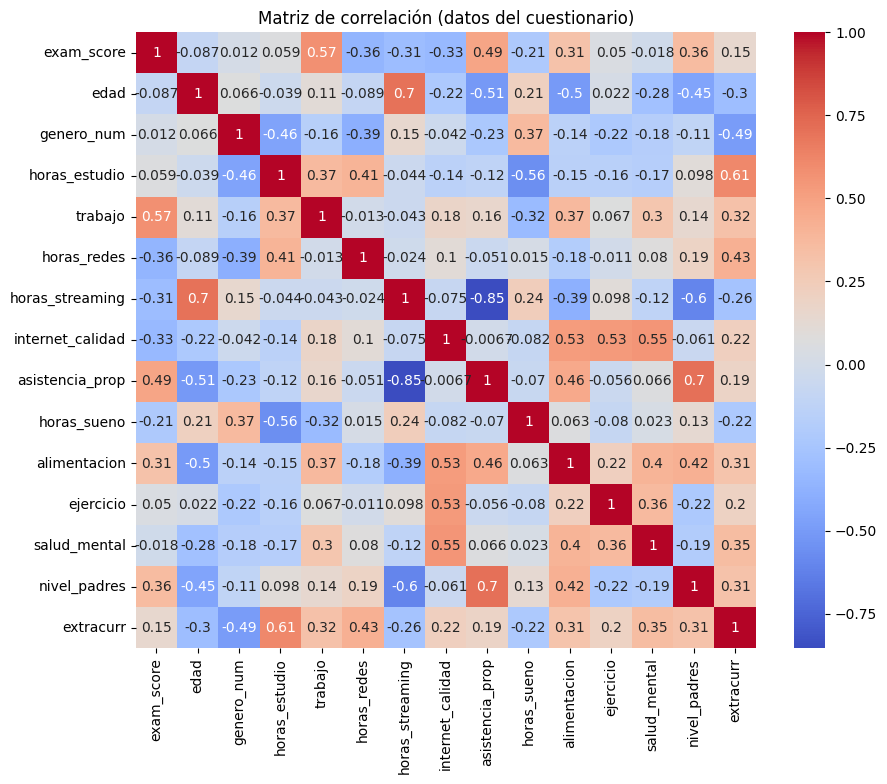

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (datos del cuestionario)")
plt.show()

In [63]:
# Simple regression: hours of study -> exam_score
X_simple = data_clean[['horas_estudio']]
y = data_clean['exam_score']

X_simple_sm = sm.add_constant(X_simple)
model_simple = sm.OLS(y, X_simple_sm).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.068
Method:                 Least Squares   F-statistic:                   0.04912
Date:                Thu, 20 Nov 2025   Prob (F-statistic):              0.828
Time:                        17:22:30   Log-Likelihood:                -67.784
No. Observations:                  16   AIC:                             139.6
Df Residuals:                      14   BIC:                             141.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            73.5147      6.929     10.610

In [64]:
# Multiple regression with selected predictors
predictors = ['horas_estudio','horas_sueno','horas_redes','horas_streaming',
              'asistencia_prop','alimentacion','ejercicio','salud_mental','trabajo']

X_mult = data_clean[predictors]
X_mult_sm = sm.add_constant(X_mult)
model_mult = sm.OLS(y, X_mult_sm).fit()
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1.272
Date:                Thu, 20 Nov 2025   Prob (F-statistic):              0.398
Time:                        17:22:40   Log-Likelihood:                -59.271
No. Observations:                  16   AIC:                             138.5
Df Residuals:                       6   BIC:                             146.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              36.1492     68.011     

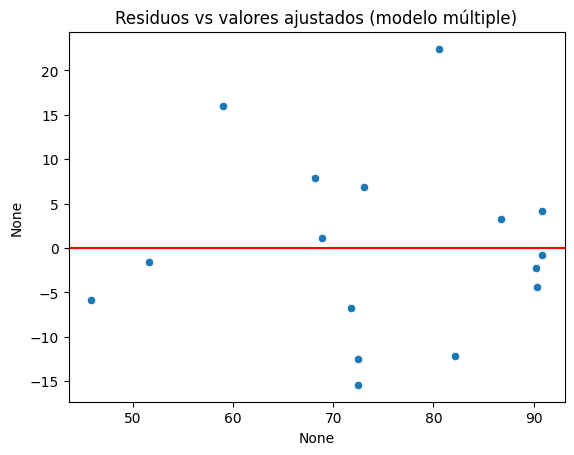

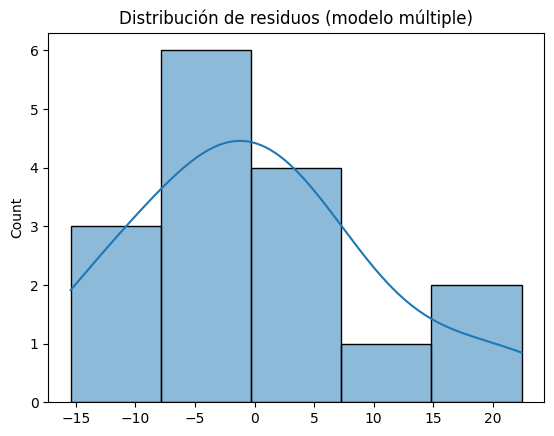

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9651775183424915), pvalue=np.float64(0.7557448239433258))
R^2: 0.6561933979873404 R^2 ajustado: 0.1404834949683511


In [51]:
# Residual diagnostics for mult model
resid = model_mult.resid
fitted = model_mult.fittedvalues

sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuos vs valores ajustados (modelo múltiple)")
plt.show()

sns.histplot(resid, kde=True)
plt.title("Distribución de residuos (modelo múltiple)")
plt.show()

print("Shapiro-Wilk:", sps.shapiro(resid))
print("R^2:", model_mult.rsquared, "R^2 ajustado:", model_mult.rsquared_adj)

In [52]:
model_mult.params

,0
const,36.149238
horas_estudio,0.764226
horas_sueno,1.403431
horas_redes,-3.156670
horas_streaming,0.421624
asistencia_prop,47.089321
alimentacion,-3.194172
ejercicio,1.508800
salud_mental,-3.439514
trabajo,21.410381


In [53]:
model_mult.pvalues

,0
const,0.614151
horas_estudio,0.869241
horas_sueno,0.824326
horas_redes,0.274002
horas_streaming,0.964890
asistencia_prop,0.415903
alimentacion,0.671668
ejercicio,0.618331
salud_mental,0.602084
trabajo,0.146734


#**Proceso**

**Preparar y limpiar los datos**

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

df = pd.read_csv("datos.csv")

# ---------- Target: puntaje de examen ----------
exam_raw = df['10. ¿Cuál fue tu último puntaje de examen importante?  '].astype(str)
exam_score = exam_raw.str.extract(r'(\d+)')[0].astype(float)   # extrae el número inicial
df['exam_score'] = exam_score

# ---------- Mapear categorías a valores numéricos ----------
map_genero = {'Femenino':0, 'Masculino':1}
map_horas_estudio = {'0 a 2':1, '2 a 3':2.5, 'más de 4':5}
map_trabajo = {'No':0, 'Sí':1}
map_redes = {'0 a 3':1.5, '4 a 5':4.5, 'más de 6':7}
map_streaming = {'0 a 2':1, '2 a 3':2.5, 'más de 4':5}
map_internet = {'Mala':1, 'Regular':2, 'Buena':3, 'Muy buena':4}
map_asistencia = {'0%  a  25%':0.125, '26%  a  50%':0.375, '51%  a  75%':0.625, '76%  a 100%':0.88}
map_sueno = {'4 a 5':4.5, 'más de 6':7}
map_alimentacion = {'Mala':1, 'Regular':2, 'Buena':3, 'Muy buena':4}
map_ejercicio = {'Nunca':0, '1–2 veces':1.5, '3–4 veces':3.5, '5 o más veces':5.5}
map_salud_mental = {'Muy mala':1, 'Mala':2, 'Regular':3, 'Buena':4, 'Excelente':5}
map_nivel_padres = {'Primaria':1, 'Secundaria':2, 'Preparatoria':3, 'Universidad':4, 'Posgrado':5,
                    'Prefiero no decir':np.nan}
map_extracurr = {'No':0, 'Sí, deportes':1, 'Sí, arte/música':1, 'Sí, clubs/voluntariado':1}

df['edad'] = df['Información general\n\n1. Ingresa tu edad']
df['genero_num'] = df['2. Género'].map(map_genero)
df['horas_estudio'] = df['Hábitos de estudio\n\n4. ¿Cuántas horas estudías al día?'].map(map_horas_estudio)
df['trabajo'] = df['5.  ¿Tienes un trabajo? '].map(map_trabajo)
df['horas_redes'] = df['Hábitos digitales\n\n6. ¿Cuántas horas pasas al día en redes sociales? '].map(map_redes)
df['horas_streaming'] = df['7.   ¿Cuántas horas ves plataformas de streaming al día? '].map(map_streaming)
df['internet_calidad'] = df['8.  ¿Cómo describirías la calidad de tu conexión a Internet? '].map(map_internet)
df['asistencia_prop'] = df['Asistencia y rendimiento académico\n\n9.  ¿Qué porcentaje de tus clases sueles asistir?'].map(map_asistencia)
df['horas_sueno'] = df['Salud y bienestar\n\n11.  ¿Cuántas horas duermes? '].map(map_sueno)
df['alimentacion'] = df['12.  ¿Cómo calificarías la calidad de tu alimentación? '].map(map_alimentacion)
df['ejercicio'] = df['13.  ¿Con qué frecuencia haces ejercicio a la semana? '].map(map_ejercicio)
df['salud_mental'] = df['14.  ¿Cómo evaluarías tu salud mental? '].map(map_salud_mental)
df['nivel_padres'] = df['Estilo de vida y familia\n\n\n15. ¿Qué nivel educativo tienen tus padres o tutores?'].map(map_nivel_padres)
df['extracurr'] = df['16.  ¿Participas en actividades extracurriculares? '].map(map_extracurr)

model_cols = ['exam_score','edad','genero_num','horas_estudio','trabajo','horas_redes',
              'horas_streaming','internet_calidad','asistencia_prop','horas_sueno',
              'alimentacion','ejercicio','salud_mental','nivel_padres','extracurr']

data_model = df[model_cols]
data_clean = data_model.dropna()   # quitamos filas con NA (quedan 16 casos)
data_clean.describe()

,exam_score,edad,genero_num,horas_estudio,trabajo,horas_redes,horas_streaming,internet_calidad,asistencia_prop,horas_sueno,alimentacion,ejercicio,salud_mental,nivel_padres,extracurr
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,74.687500,23.125000,0.687500,1.843750,0.687500,2.562500,1.531250,2.562500,0.769062,6.531250,2.437500,2.562500,3.375000,3.625000,0.437500
std,17.315576,3.422962,0.478714,1.609542,0.478714,2.007278,1.102554,0.629153,0.184067,1.007782,0.813941,1.682013,0.885061,1.087811,0.512348
min,40.000000,19.000000,0.000000,1.000000,0.000000,1.500000,1.000000,1.000000,0.375000,4.500000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,63.750000,21.000000,0.000000,1.000000,0.000000,1.500000,1.000000,2.000000,0.625000,7.000000,2.000000,1.500000,3.000000,3.000000,0.000000
50%,75.500000,22.500000,1.000000,1.000000,1.000000,1.500000,1.000000,3.000000,0.880000,7.000000,2.000000,2.500000,3.000000,4.000000,0.000000
75%,88.500000,24.250000,1.000000,1.375000,1.000000,2.250000,1.375000,3.000000,0.880000,7.000000,3.000000,3.500000,4.000000,4.000000,1.000000
max,103.000000,32.000000,1.000000,5.000000,1.000000,7.000000,5.000000,3.000000,0.880000,7.000000,4.000000,5.500000,5.000000,5.000000,1.000000


**Matriz de correlación**

In [58]:
corr = data_clean.corr()
print(corr['exam_score'].sort_values(ascending=False))

exam_score          1.000000
trabajo             0.574543
asistencia_prop     0.485067
nivel_padres        0.361452
alimentacion        0.313080
extracurr           0.151701
horas_estudio       0.059128
ejercicio           0.049928
genero_num          0.011561
salud_mental       -0.017944
edad               -0.087030
horas_sueno        -0.209523
horas_streaming    -0.308495
internet_calidad   -0.331600
horas_redes        -0.358079
Name: exam_score, dtype: float64


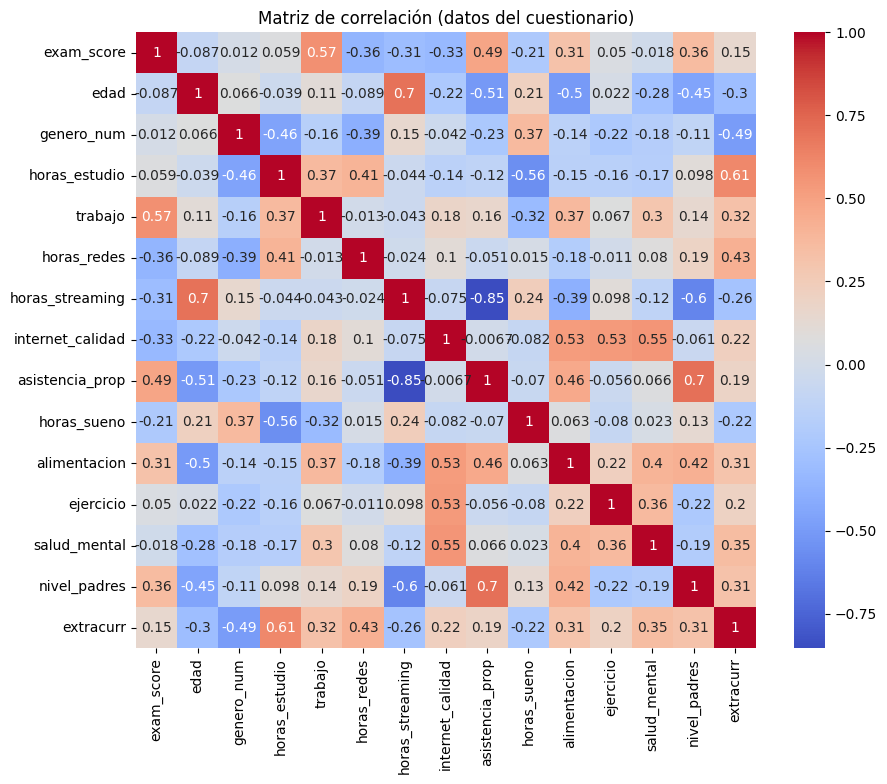

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (datos del cuestionario)")
plt.show()

Interpretación.

En esta muestra pequeña, los alumnos que tienen trabajo y los que asisten a mayor proporción de clases tienden a reportar puntajes de examen más altos.

También se observa que padres con mayor nivel educativo y una mejor alimentación se relacionan positivamente con el puntaje.

En sentido contrario, más horas en redes sociales y streaming se asocian con puntajes algo menores.

Las horas de estudio, al menos en este grupo, no muestran una correlación clara con el resultado del examen (correlación casi nula).

**Regresión lineal simple**

Puntaje de examen ~ horas de sueño

In [60]:
X_simple = data_clean[['horas_estudio']]
y = data_clean['exam_score']

X_simple_sm = sm.add_constant(X_simple)
model_simple = sm.OLS(y, X_simple_sm).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.068
Method:                 Least Squares   F-statistic:                   0.04912
Date:                Thu, 20 Nov 2025   Prob (F-statistic):              0.828
Time:                        16:45:50   Log-Likelihood:                -67.784
No. Observations:                  16   AIC:                             139.6
Df Residuals:                      14   BIC:                             141.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            73.5147      6.929     10.610

Interpretación

El modelo sugiere que, en promedio, cada unidad adicional en la escala de horas de estudio se asocia con un aumento de solo 0.64 puntos en el puntaje de examen.

Sin embargo, el p-value es 0.828 (> 0.05) → la relación NO es estadísticamente significativa.

El R² ≈ 0.003 indica que el modelo prácticamente no explica la variabilidad del puntaje.

Conclusión: con estos datos, no se puede afirmar que estudiar más horas (según cómo respondieron) esté asociado a un mejor puntaje en el último examen.

**Regresión lineal multiple**

Puntaje de examen explicada por varios hábitos

In [61]:
predictors = ['horas_estudio','horas_sueno','horas_redes','horas_streaming',
              'asistencia_prop','alimentacion','ejercicio','salud_mental','trabajo']

X_mult = data_clean[predictors]
X_mult_sm = sm.add_constant(X_mult)
model_mult = sm.OLS(y, X_mult_sm).fit()
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1.272
Date:                Thu, 20 Nov 2025   Prob (F-statistic):              0.398
Time:                        16:47:41   Log-Likelihood:                -59.271
No. Observations:                  16   AIC:                             138.5
Df Residuals:                       6   BIC:                             146.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              36.1492     68.011     

R² = 0.656 (el modelo explica ~65.6% de la variabilidad)

R² ajustado ≈ 0.14 (baja mucho por la muestra pequeña y muchos predictores)

Ningún predictor tiene p-value < 0.05
– el más cercano es trabajo con p ≈ 0.147 (tendencia pero no significativo).

**Interpretación general**

El modelo múltiple sugiere patrones interesantes (que concuerdan con las correlaciones):

Más horas en redes tienden a reducir el puntaje (coef. ≈ –3.16).

Mayor asistencia se asocia con puntajes más altos (coef. ≈ 47, pero con mucha incertidumbre).

Tener trabajo se relaciona con ~21 puntos extra en promedio, aunque esto no es concluyente.

Sin embargo, ninguna de estas relaciones es estadísticamente significativa al 5% debido a que solo hay 16 observaciones y 9 predictores (= poca potencia estadística).

El R² alto pero R² ajustado bajo indica que el modelo podría estar sobreajustado para un tamaño de muestra tan pequeño.

**Validación del modelo multiple**

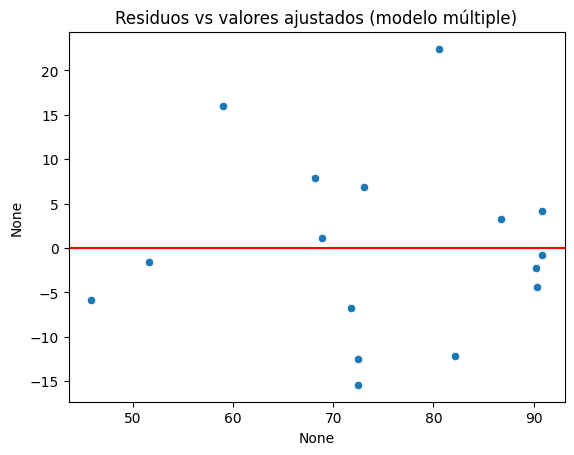

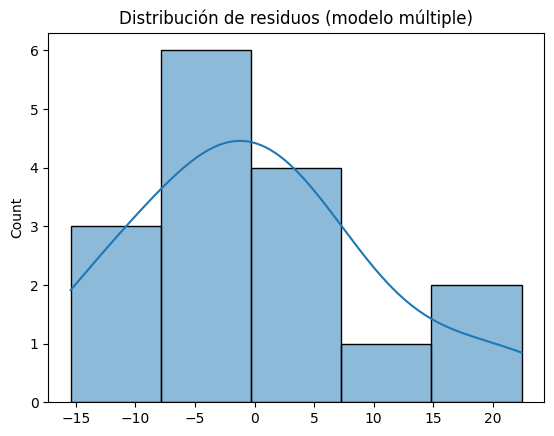

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9651775183424915), pvalue=np.float64(0.7557448239433258))
R^2: 0.6561933979873404 R^2 ajustado: 0.1404834949683511


In [62]:
resid = model_mult.resid
fitted = model_mult.fittedvalues

# 1) Residuos vs valores ajustados
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuos vs valores ajustados (modelo múltiple)")
plt.show()

# 2) Histograma de residuos
sns.histplot(resid, kde=True)
plt.title("Distribución de residuos (modelo múltiple)")
plt.show()

# 3) Normalidad (Shapiro-Wilk)
print("Shapiro-Wilk:", stats.shapiro(resid))

# 4) R^2
print("R^2:", model_mult.rsquared, "R^2 ajustado:", model_mult.rsquared_adj)


Resultados importantes:

Shapiro-Wilk p-value ≈ 0.756 > 0.05
→ No se rechaza la normalidad de los residuos.

La nube de residuos vs ajustados no muestra patrón claro
→ Homocedasticidad razonable.

R² ≈ 0.656, R² ajustado ≈ 0.14 → el modelo explica bastante variación, pero al ajustar por número de variables la calidad baja.

**Interpretación completa**

El modelo de regresión múltiple cumple de manera razonable los supuestos de normalidad y homocedasticidad de los residuos.
Sin embargo, debido al tamaño reducido de la muestra (n = 16) y al número relativamente grande de predictores, los coeficientes estimados presentan alta incertidumbre y ninguno resulta estadísticamente significativo al nivel α = 0.05.
Por ello, las conclusiones deben tomarse como tendencias exploratorias, no como evidencia definitiva.

##**Conclusión general**

A partir del cuestionario aplicado, se construyó un conjunto de variables numéricas que representan distintos hábitos de estudio, uso de tecnología y condiciones de salud y contexto familiar. El análisis de correlación mostró que el puntaje del último examen se relaciona positivamente con la asistencia a clases, el hecho de tener trabajo y el nivel educativo de los padres, mientras que el uso intensivo de redes sociales y plataformas de streaming se asocia de manera negativa con el rendimiento.

No obstante, al ajustar modelos de regresión lineal simple y múltiple, ninguna de las variables resultó estadísticamente significativa, debido principalmente al tamaño reducido de la muestra (n = 16). Aunque el modelo múltiple alcanza un R² cercano a 0.66, el R² ajustado (~0.14) y los altos p-values sugieren que los resultados deben interpretarse con cautela y considerarse exploratorios.

En síntesis, los datos indican ciertas tendencias coherentes con la literatura —como la posible influencia negativa del uso excesivo de redes sociales y la importancia de la asistencia—, pero se requiere una muestra más grande para confirmar de manera robusta el efecto de los hábitos de vida sobre el puntaje de examen.